In [2]:
import numpy as np
from typing import Tuple, Optional
import matplotlib.pyplot as plt

In [ ]:
class MM_Weibull:

    
    def __init__(self, data: np.ndarray):
        self.data = np.asarray(data, dtype=float)
        self.n = len(self.data)
        
        # Precompute constants
        self.sum_log_x = np.sum(np.log(self.data))
        self.mean_log_x = self.sum_log_x / self.n
        
        # Store estimates
        self.k = None
        self.lmbda = None
    
    def _mm_update_kappa(self, kappa_current: float) -> float:

        # Numerator: sum x_i^{k_n} ln(x_i)
        numerator = np.sum(np.power(self.data, kappa_current) * np.log(self.data))
        
        # Denominator: sum x_i^{k_n}
        denominator = np.sum(np.power(self.data, kappa_current))
        
        # MM update formula
        inverse_k_new = numerator / denominator - self.mean_log_x
        
        if inverse_k_new <= 0:
            raise ValueError("Non-positive kappa. Try different initial value.")
            
        return 1.0 / inverse_k_new
    
    def _estimate_lambda(self, kappa: float) -> float:
        mean_x_power_k = np.mean(np.power(self.data, kappa))
        return np.power(mean_x_power_k, 1.0 / kappa)
    
    def log_likelihood(self, kappa: float, lmbda: float) -> float:
        term1 = self.n * np.log(kappa)
        term2 = -self.n * kappa * np.log(lmbda)
        term3 = (kappa - 1) * self.sum_log_x
        term4 = -np.sum(np.power(self.data / lmbda, kappa))
        return term1 + term2 + term3 + term4
    
    def fit(self, k_init: float = 1.0, max_iter: int = 100, tol: float = 1e-6, verbose: bool = True) -> Tuple[float, float]:

        k_current = k_init
        
        if verbose:
            print(f"{'Itereation':<10} {'k':<10} {'lambda':<10} {'delta_k':<10} {'LogLikelihood':<10}")
            print("------------------------------------------")
        
        for iteration in range(max_iter):
            # Compute optimal lambda for current k
            lmbda_current = self._estimate_lambda(k_current)
            
            # Perform MM update for k
            k_new = self._mm_update_kappa(k_current)
            
            delta = abs(k_new - k_current)
            ll = self.log_likelihood(k_new, lmbda_current)
            
            if verbose:
                print(f"{iteration:<10.4f} {k_new:<10.4f} {lmbda_current:<10.4f} {delta:<10.6f} {ll:<10.4f}")
            
            # Check convergence
            if delta < tol:
                self.k = k_new
                self.lmbda = lmbda_current
                
                if verbose:
                    print(f"\n Converged after {iteration + 1} iterations")
                
                break
            
            k_current = k_new
        
        if iteration == max_iter - 1:
            print(f"\nWarning: Did not converge within {max_iter} iterations")
        
        self.k = k_new
        self.lmbda = self._estimate_lambda(k_new)
        
        return self.k, self.lmbda
    
    def get_params(self) -> Tuple[float, float]:
        if self.k is None or self.lmbda is None:
            raise RuntimeError("Call fit() first before get_params()")
        return (self.k, self.lmbda)

In [22]:
if __name__ == "__main__":
    # Generate sample data
    np.random.seed(117)
    k_true = 2.5
    lambda_true = 1.8
    data = lambda_true * np.random.weibull(k_true, size=2000)
    
    print("###########################################")
    print("MM ALGORITHM - Weibull Parameter Estimation")
    print("###########################################")
    
    # Fit the model
    model = MM_Weibull(data)
    k_hat, lambda_hat = model.fit(k_init=1.0, verbose=True)
    
    print("\n" + "-----------------------------------------------------")
    print("RESULTS:")
    print(f"True     : k = {k_true:.4f}, λ = {lambda_true:.4f}")
    print(f"Estimated: k = {k_hat:.4f}, λ = {lambda_hat:.4f}")
    print(f"Error    : k = {(k_hat-k_true)/k_true*100:+.2f}%, λ = {(lambda_hat-lambda_true)/lambda_true*100:+.2f}%")
    print("---------------------------------------------------")
    
    # Verify the parameters
    k_out, l_out = model.get_params()
    print(f"get_params() correctly returns: ({k_out:.4f}, {l_out:.4f})")



###########################################
MM ALGORITHM - Weibull Parameter Estimation
###########################################
Itereation k          lambda     delta_k    LogLikelihood
------------------------------------------
0.0000     4.8900     1.5932     3.890019   -5350.5932
1.0000     1.6987     2.0420     3.191272   -2321.5313
2.0000     3.3027     1.6911     1.603984   -2289.1235
3.0000     2.1433     1.8811     1.159408   -2080.4744
4.0000     2.8196     1.7477     0.676239   -2052.2084
5.0000     2.3631     1.8276     0.456437   -2027.4969
6.0000     2.6447     1.7744     0.281544   -2021.0194
7.0000     2.4604     1.8076     0.184236   -2017.4569
8.0000     2.5766     1.7860     0.116154   -2016.2429
9.0000     2.5016     1.7997     0.075014   -2015.6830
10.0000    2.5493     1.7909     0.047710   -2015.4704
11.0000    2.5186     1.7965     0.030644   -2015.3791
12.0000    2.5382     1.7929     0.019559   -2015.3428
13.0000    2.5257     1.7952     0.012535   -2015.32

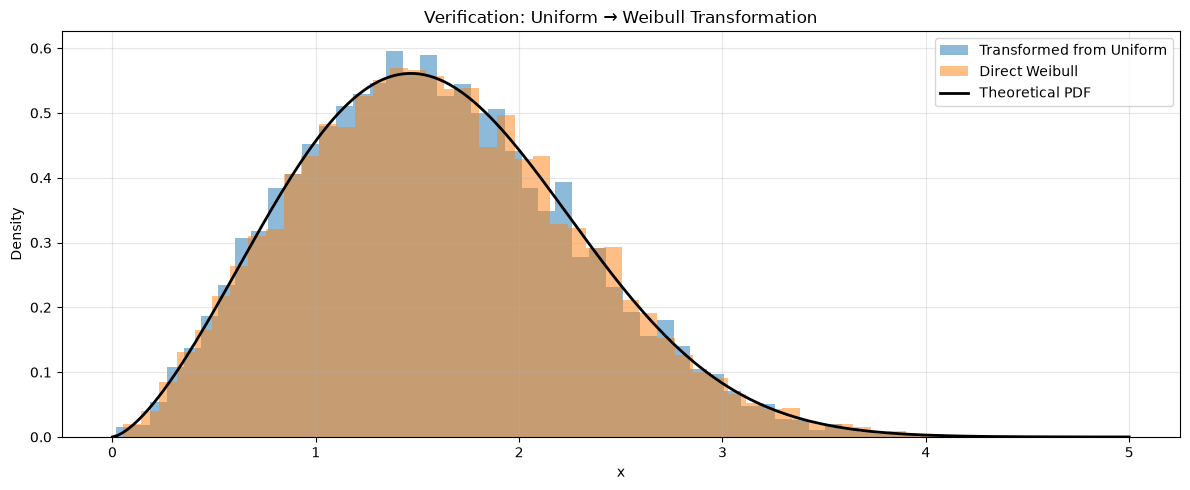

Mean of transformed:  1.5827 (Expected: 1.5969)
Std of transformed:   0.6770


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
kappa_true = 2.5
lambda_true = 1.8
n_samples = 10000

# Method 1: Generate from Uniform and transform
np.random.seed(42)
U = np.random.uniform(0, 1, n_samples)
X_transformed = lambda_true * (-np.log(1 - U))**(1/kappa_true)

# Method 2: Use numpy's weibull directly (for comparison)
X_direct = lambda_true * np.random.weibull(kappa_true, n_samples)

# Compare distributions
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram of transformed
ax.hist(X_transformed, bins=50, alpha=0.5, density=True, label='Transformed from Uniform')

# Histogram of direct
ax.hist(X_direct, bins=50, alpha=0.5, density=True, label='Direct Weibull')

# True PDF curve
x_vals = np.linspace(0, 5, 200)
pdf_vals = stats.weibull_min.pdf(x_vals, kappa_true, scale=lambda_true)
ax.plot(x_vals, pdf_vals, 'k-', linewidth=2, label='Theoretical PDF')

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Verification: Uniform → Weibull Transformation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical test
print(f"Mean of transformed:  {np.mean(X_transformed):.4f} (Expected: {lambda_true * np.mean(np.random.weibull(kappa_true, 10000)):.4f})")
print(f"Std of transformed:   {np.std(X_transformed):.4f}")